In [1]:
from experiments.dj.likelihood_tables import LikelihoodConfig
from experiments.dj.result_tables import (
    AdaptPriorResult,
    FlowPriorResult,
    LikelihoodResult,
)
from experiments.dj.prior_tables import FlowPriorConfig
from experiments.dj.trainer_tables import FPTrainerConfig, LLTrainerConfig
from experiments.dj.dataloader_tables import DataLoaderConfig
from experiments.dj.dj_helpers import fetch_best_model_results
import gensn.distributions as G
import torch
from task_transfer.ml_lib.data_loading import build_dataloaders
from task_transfer.evaluation.evaluate_generative_model import (
    evaluate_flow_prior,
    compute_logl,
    adapt_prior_eval_criterion,
    compute_joint_logl,
    logl_mc_marginal_eval,
)

[2024-07-04 12:59:00,317][INFO]: Connecting sshrinivasan@134.76.19.44:3306
[2024-07-04 12:59:00,414][INFO]: Connected sshrinivasan@134.76.19.44:3306


In [2]:
FlowPriorResult()

fp_id,trainer_id,dl_id,"train_ll_mean mean per dimension, per sample, in nats",train_ll_sem standard error of the mean,val_ll_mean,val_ll_sem,test_ll_mean,test_ll_sem,tracker_output,eval_output,model
0173a9aecec7a4e144011e0d3ff0c8a7,c40a50ce9c77369770dddd5129836477,260a5ea8175f75eaef132f42873ad14a,-51.72239303588867,1.2013747692108154,-51.840248107910156,2.282120943069458,-51.840248107910156,2.282120943069458,=BLOB=,=BLOB=,=BLOB=
0173a9aecec7a4e144011e0d3ff0c8a7,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-52.199527740478516,1.2041391134262085,-52.2991943359375,2.289771556854248,-52.2991943359375,2.289771556854248,=BLOB=,=BLOB=,=BLOB=
036827f08f256e836cacde3d2954ea4a,c40a50ce9c77369770dddd5129836477,260a5ea8175f75eaef132f42873ad14a,-72.07315826416016,1.3810926675796509,-71.84971618652344,2.6091067790985107,-71.84971618652344,2.6091067790985107,=BLOB=,=BLOB=,=BLOB=
036827f08f256e836cacde3d2954ea4a,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-72.36489868164062,1.463006615638733,-72.16575622558594,2.690886974334717,-72.16575622558594,2.690886974334717,=BLOB=,=BLOB=,=BLOB=
0626e82eec85ade7041703d85e168d5b,c40a50ce9c77369770dddd5129836477,260a5ea8175f75eaef132f42873ad14a,-126.7267837524414,1.5894485712051392,-126.70783996582031,2.9417123794555664,-126.70783996582031,2.9417123794555664,=BLOB=,=BLOB=,=BLOB=
0626e82eec85ade7041703d85e168d5b,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-123.26030731201172,1.62436842918396,-123.29173278808594,3.0070111751556396,-123.29173278808594,3.0070111751556396,=BLOB=,=BLOB=,=BLOB=
06bb4905529cab2d09a6b5fb479cd700,c40a50ce9c77369770dddd5129836477,260a5ea8175f75eaef132f42873ad14a,-74.34554290771484,1.4281342029571533,-74.0283432006836,2.6899912357330322,-74.0283432006836,2.6899912357330322,=BLOB=,=BLOB=,=BLOB=
06bb4905529cab2d09a6b5fb479cd700,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-71.88994598388672,1.4057899713516235,-71.6804428100586,2.6343274116516113,-71.6804428100586,2.6343274116516113,=BLOB=,=BLOB=,=BLOB=
06fe441dd0fdca3ae7bfa7a4ad856467,c40a50ce9c77369770dddd5129836477,260a5ea8175f75eaef132f42873ad14a,-55.91200256347656,1.221100091934204,-56.58893966674805,2.382314443588257,-56.58893966674805,2.382314443588257,=BLOB=,=BLOB=,=BLOB=
06fe441dd0fdca3ae7bfa7a4ad856467,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-5981.26806640625,212.3249969482422,-6216.796875,713.691162109375,-6216.796875,713.691162109375,=BLOB=,=BLOB=,=BLOB=


In [3]:
download_path = "/tmp"
criterion = "val_ll_mean"
k = 1

prior_config_proj_col = "fp_id"
best_val_prior_results = fetch_best_model_results(
    result_table=FlowPriorResult,
    config_table=FlowPriorConfig,
    data_loader_config_table=DataLoaderConfig,
    trainer_config_table=FPTrainerConfig,
    config_proj_col=prior_config_proj_col,
    criterion=criterion,
    k=k,
    download_path=download_path,
)
pre_task_trained_prior = torch.load(best_val_prior_results["model"], map_location="cpu")

# Check marginal conditional and conditional lps for pre-task trained flow model on new task vs data-based ones

In [4]:
dataloader_args = {
    "data_fname": "/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_1_dataset.pkl",
    "train_prop": 0.7,
    "val_prop": 0.2,
}
train_loader, val_loader, test_loader = build_dataloaders(
    data_fname=dataloader_args["data_fname"],
    train_prop=dataloader_args["train_prop"],
    val_prop=dataloader_args["val_prop"],
    batch_size=128,
)

In [5]:
# get likelihood model for marginal likelihood
likelihood_config_proj_col = "ll_id"
best_val_likelihood_results = fetch_best_model_results(
    result_table=LikelihoodResult,
    config_table=LikelihoodConfig,
    data_loader_config_table=DataLoaderConfig,
    trainer_config_table=LLTrainerConfig,
    config_proj_col=likelihood_config_proj_col,
    criterion=criterion,
    k=k,
    download_path=download_path,
)
likelihood_model = torch.load(best_val_likelihood_results["model"], map_location="cpu")

In [6]:
pre_task_trained_joint = G.Joint(prior=pre_task_trained_prior, conditional=likelihood_model)

In [7]:
import wandb
wandb.init(project="random", entity="walkerlab")

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


wandb: Currently logged in as: sshr (walkerlab). Use `wandb login --relogin` to force relogin


In [8]:
data_dim = 1
cond_dim = 0
mc_sample_size=(50_000),
device="cpu"
reduction="none"
uncertainty="sem"
normalize="none"
unit="nats"
logl_mc_marg_pre_task_train, _ = logl_mc_marginal_eval(
    joint_model=pre_task_trained_joint,
    data_loader=train_loader,
    data_dim=data_dim,
    mc_sample_size=mc_sample_size,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
logl_mc_marg_pre_task_val, _ = logl_mc_marginal_eval(
    joint_model=pre_task_trained_joint,
    data_loader=val_loader,
    data_dim=data_dim,
    mc_sample_size=mc_sample_size,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
logl_mc_marg_pre_task_test, _ = logl_mc_marginal_eval(
    joint_model=pre_task_trained_joint,
    data_loader=test_loader,
    data_dim=data_dim,
    mc_sample_size=mc_sample_size,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

In [9]:
import numpy as np

def compute_logl_data_marginal(
    conditional_model, 
    data_loader, 
    data_dim,
    cond_dim,
    device="cpu",
    reduction="mean",
    uncertainty="sem",
    normalize="none",
    unit="nats",
):
    log_probs = []
    for batch in data_loader:
        data = batch[data_dim].to(device)
        cond = batch[cond_dim].to(device)
        conditional_ll = conditional_model(data, cond=cond.unsqueeze(1))
        marginal_ll = torch.logsumexp(conditional_ll, dim=0) - torch.log(
            torch.tensor(conditional_ll.shape[0])
        )
        log_probs.append(marginal_ll)
        if reduction == "mean":
            lp = torch.cat(log_probs).mean().item()
        elif reduction == "sum":
            lp = torch.cat(log_probs).sum().item()
        elif reduction == "none":
            lp = torch.cat(log_probs)
        else:
            raise ValueError("Unknown reduction")
        if uncertainty == "sem":
            lp_uncertainty = torch.cat(log_probs).std() / (len(log_probs) ** 0.5)
            lp_uncertainty = lp_uncertainty.item()
        elif uncertainty == "std":
            lp_uncertainty = torch.cat(log_probs).std()
            lp_uncertainty = lp_uncertainty.item()
        elif uncertainty == "none":
            lp_uncertainty = None
        else:
            raise ValueError("Unknown uncertainty measure")
        if normalize == "per_dim":
            batch = next(iter(data_loader))
            data = batch[data_dim]
            lp /= data.shape[1:].numel()
        elif normalize == "none":
            pass
        elif normalize == "per_dim":
            n_dims = data.shape[1:].numel()
            lp /= n_dims
        if unit == "nats":
            pass
        elif unit == "bits":
            lp /= np.log(2)
        else:
            raise ValueError("Unknown unit")
    return lp, lp_uncertainty

In [10]:
logl_data_marg_train, _ = compute_logl_data_marginal(
    conditional_model=likelihood_model,
    data_loader=train_loader,
    data_dim=data_dim,
    cond_dim=cond_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
logl_data_marg_val, _ = compute_logl_data_marginal(
    conditional_model=likelihood_model,
    data_loader=val_loader,
    data_dim=data_dim,
    cond_dim=cond_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
logl_data_marg_test, _ = compute_logl_data_marginal(
    conditional_model=likelihood_model,
    data_loader=test_loader,
    data_dim=data_dim,
    cond_dim=cond_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

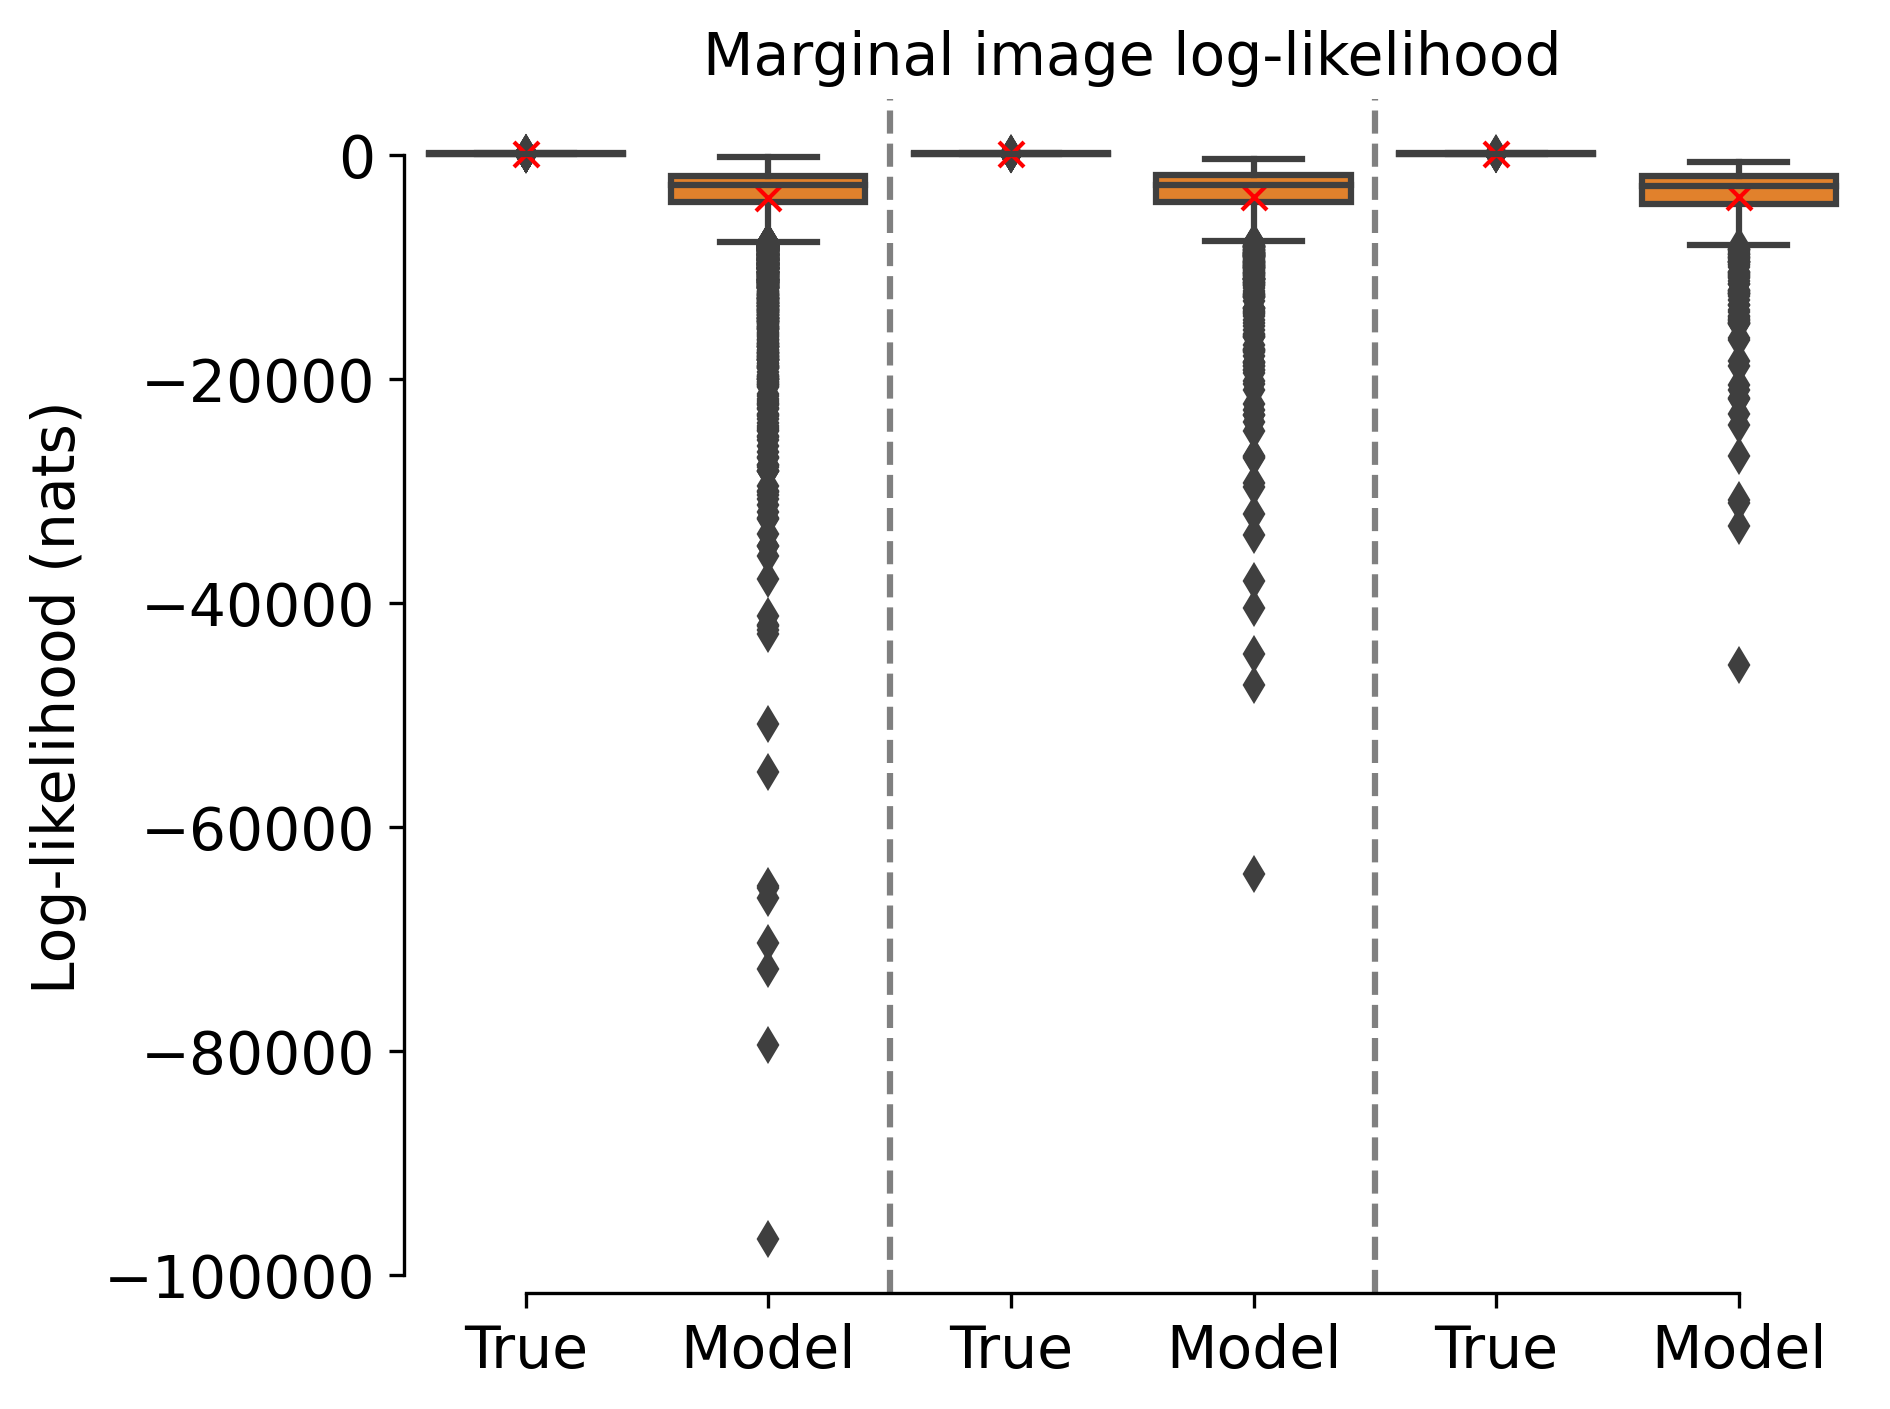

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

data = [
    logl_data_marg_train.detach(),
    logl_mc_marg_pre_task_train.detach(),
    logl_data_marg_val.detach(),
    logl_mc_marg_pre_task_val.detach(),
    logl_data_marg_test.detach(),
    logl_mc_marg_pre_task_test.detach(),
]
labels = [
    "True",
    "Model",
    "True",
    "Model",
    "True",
    "Model",
]
# Creating a boxplot
fig, ax = plt.subplots(dpi=300)
# set two colors as palette and cycle
palette = sns.color_palette("tab10", n_colors=2)
ax = sns.boxplot(data=data, ax=ax, palette=palette)
# add mean values
for i, value in enumerate(data):
    # ax.text(i + 0.3, value.mean() + 0.5, f"{value.mean():.2f}", ha="center", va="bottom", fontsize=8)
    # add a red dot
    ax.plot(i, value.mean(), "rx")
ax.set_xticklabels(labels)
ax.set_title("Marginal image log-likelihood", fontsize=14)
ax.set_ylabel("Log-likelihood (nats)", fontsize=14)
ax.tick_params(axis="both", which="major", labelsize=14)
for tick in range(len(labels)):
    if tick % 2 == 0 and tick != 0:
        ax.axvline(tick - 0.5, ls="--", color="grey")
# ax.set_yticks(range(-100, 0, 10))
sns.despine(ax=ax, trim=True)
plt.tight_layout()

# # Display the plot
# plt.show()

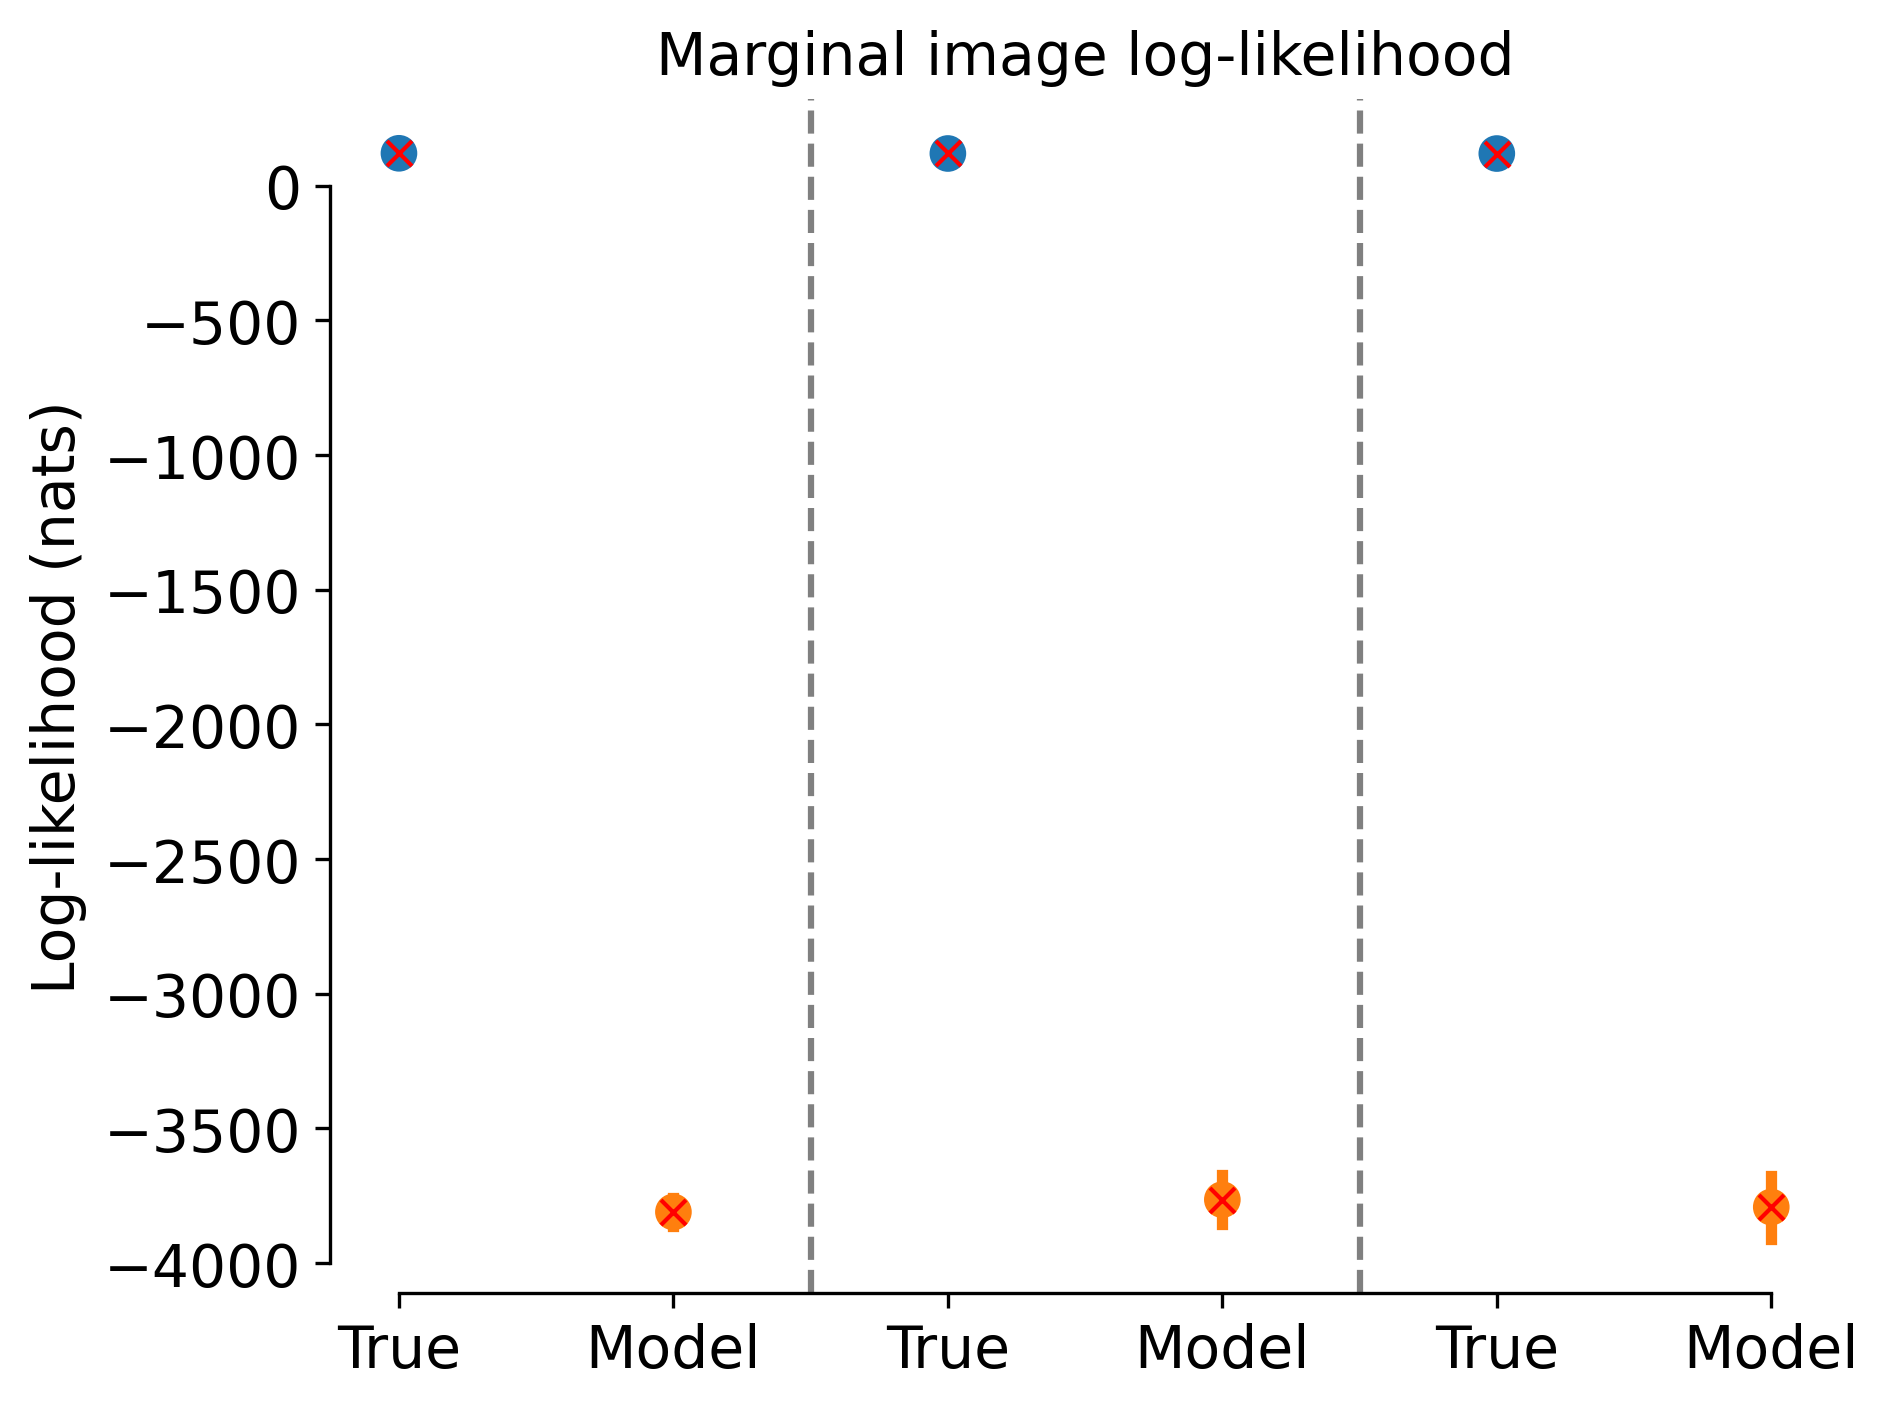

In [16]:
data = [
    logl_data_marg_train.detach(),
    logl_mc_marg_pre_task_train.detach(),
    logl_data_marg_val.detach(),
    logl_mc_marg_pre_task_val.detach(),
    logl_data_marg_test.detach(),
    logl_mc_marg_pre_task_test.detach(),
]
labels = [
    "True",
    "Model",
    "True",
    "Model",
    "True",
    "Model",
]
# Creating a boxplot
fig, ax = plt.subplots(dpi=300)
# set two colors as palette and cycle
palette = sns.color_palette("tab10", n_colors=2)
ax = sns.pointplot(data=data, ax=ax, palette=palette, errorbar="se")
# add mean values
for i, value in enumerate(data):
    # ax.text(i + 0.3, value.mean() + 0.5, f"{value.mean():.2f}", ha="center", va="bottom", fontsize=8)
    # add a red dot
    ax.plot(i, value.mean(), "rx")
ax.set_xticklabels(labels)
ax.set_title("Marginal image log-likelihood", fontsize=14)
ax.set_ylabel("Log-likelihood (nats)", fontsize=14)
ax.tick_params(axis="both", which="major", labelsize=14)
for tick in range(len(labels)):
    if tick % 2 == 0 and tick != 0:
        ax.axvline(tick - 0.5, ls="--", color="grey")
# ax.set_yticks(range(-100, 0, 10))
sns.despine(ax=ax, trim=True)
plt.tight_layout()

# # Display the plot
# plt.show()

In [4]:
best_val_prior_results

{'fp_id': '89c1053a65023b042dc63f7f852bb5b0',
 'trainer_id': 'f89651063b51487dcdf4041336ef89db',
 'dl_id': '260a5ea8175f75eaef132f42873ad14a',
 'train_ll_mean': -51.37348556518555,
 'train_ll_sem': 1.190269112586975,
 'val_ll_mean': -51.278499603271484,
 'val_ll_sem': 2.2305781841278076,
 'test_ll_mean': -51.278499603271484,
 'test_ll_sem': 2.2305781841278076,
 'tracker_output': '/tmp/89c1053a65023b042dc63f7f852bb5b0_f89651063b51487dcdf4041336ef89db_260a5ea8175f75eaef132f42873ad14a_tracker_output.pkl',
 'eval_output': '/tmp/89c1053a65023b042dc63f7f852bb5b0_f89651063b51487dcdf4041336ef89db_260a5ea8175f75eaef132f42873ad14a_eval_output.pkl',
 'model': '/tmp/89c1053a65023b042dc63f7f852bb5b0_f89651063b51487dcdf4041336ef89db_260a5ea8175f75eaef132f42873ad14a_model.pt',
 'seed': 42,
 'flow_depth': 2,
 'flow_initial_nonlin': 'inv_softplus',
 'flow_final_nonlin': 'none',
 'flow_nonlin': 'tanh',
 'flow_base_dist': 'multivariate_normal',
 'affine_type': 'factorized',
 'data_fname': '/src/project/d

In [15]:
pre_prior_model = torch.load(best_val_prior_results["model"], map_location="cpu")

In [5]:
likelihood_config_proj_col = "ll_id"
best_val_likelihood_results = fetch_best_model_results(
    result_table=LikelihoodResult,
    config_table=LikelihoodConfig,
    data_loader_config_table=DataLoaderConfig,
    trainer_config_table=LLTrainerConfig,
    config_proj_col=likelihood_config_proj_col,
    criterion=criterion,
    k=k,
    download_path=download_path,
)

In [21]:
best_val_likelihood_results

{'ll_id': 'a67b8eaff13e89e7272e90768c2ab280',
 'trainer_id': 'f89651063b51487dcdf4041336ef89db',
 'dl_id': '260a5ea8175f75eaef132f42873ad14a',
 'train_ll_mean': 125.39987182617188,
 'train_ll_sem': 1.1455481052398682,
 'val_ll_mean': 124.65189361572266,
 'val_ll_sem': 2.2731430530548096,
 'test_ll_mean': 124.65189361572266,
 'test_ll_sem': 2.2731430530548096,
 'tracker_output': '/tmp/a67b8eaff13e89e7272e90768c2ab280_f89651063b51487dcdf4041336ef89db_260a5ea8175f75eaef132f42873ad14a_tracker_output.pkl',
 'eval_output': '/tmp/a67b8eaff13e89e7272e90768c2ab280_f89651063b51487dcdf4041336ef89db_260a5ea8175f75eaef132f42873ad14a_eval_output.pkl',
 'model': '/tmp/a67b8eaff13e89e7272e90768c2ab280_f89651063b51487dcdf4041336ef89db_260a5ea8175f75eaef132f42873ad14a_model.pt',
 'seed': 42,
 'cond_dist': 'indep_normal',
 'nonneg_transform': 'exp',
 'n_layers': 1,
 'nonlin': 'none',
 'dropout_rate': 0.0,
 'init_std': 0.001,
 'kwargs': {'clamp_pre_scale': True, 'pre_scale_max': 10.0},
 'data_fname': '/sr

In [6]:
pre_likelihood_model = torch.load(best_val_likelihood_results["model"], map_location="cpu")

In [7]:
pre_likelihood_model

IndependentNormal(
  (trainable_distribution): IndependentTrainableDistributionAdapter(
    distribution_class=<class 'torch.distributions.normal.Normal'>, event_dims=1
    (parameter_generator): LocScale(
      (core_nn): MLP(
        (core_module): Sequential(
          (linear_0): Linear(in_features=45, out_features=144, bias=True)
          (dropout_0): Dropout(p=0.0, inplace=False)
          (nonlin_0): Identity()
        )
      )
      (loc_module): Linear(in_features=144, out_features=144, bias=True)
      (pre_scale_module): Linear(in_features=144, out_features=144, bias=True)
    )
  )
)

In [8]:
AdaptPriorResult()

seed,prior_fp_id to index into FlowPriorConfig,prior_trainer_id to index into FPTrainerConfig,likelihood_id to index into LikelihoodConfig,likelihood_trainer_id to index into LLTrainerConfig,orig_dl_id to index into DataLoaderConfig used for the prior and likelihood training,trainer_id,dl_id,"train_marginal_obs_ll_mean mean per trial, per sample, in nats",train_marginal_obs_ll_sem standard error of the mean,val_marginal_obs_ll_mean,val_marginal_obs_ll_sem,test_marginal_obs_ll_mean,test_marginal_obs_ll_sem,"train_prior_ll_mean mean per trial, per sample, in nats",train_prior_ll_sem standard error of the mean,val_prior_ll_mean,val_prior_ll_sem,test_prior_ll_mean,test_prior_ll_sem,tracker_output,eval_output,model trained joint model NOT just the prior
42,89c1053a65023b042dc63f7f852bb5b0,f89651063b51487dcdf4041336ef89db,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,a7e83afb3d10e49d76cbfbe16c294932,9ef3ae6fea33eba634d928a88b866836,-4562.9326171875,519.796630859375,-4448.28369140625,939.2865600585938,-4520.61865234375,1359.6124267578125,-743.2742919921875,75.81260681152344,-747.7225341796875,142.95977783203125,-755.2362670898438,198.4233856201172,=BLOB=,=BLOB=,=BLOB=
42,89c1053a65023b042dc63f7f852bb5b0,f89651063b51487dcdf4041336ef89db,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,b4400f97d2c4a40c100d69b05687bac2,9ef3ae6fea33eba634d928a88b866836,-4420.30810546875,463.8482971191406,-4414.55029296875,912.3672485351562,-4375.9580078125,1156.122802734375,-64056.23828125,7939.8671875,-63959.0,14570.203125,-62753.640625,20335.9609375,=BLOB=,=BLOB=,=BLOB=
100,89c1053a65023b042dc63f7f852bb5b0,f89651063b51487dcdf4041336ef89db,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,a7e83afb3d10e49d76cbfbe16c294932,9ef3ae6fea33eba634d928a88b866836,-4471.7607421875,498.8870544433594,-4397.88623046875,866.5904541015625,-4429.8603515625,1213.0550537109375,-70023.875,12214.7607421875,-70749.96875,23362.755859375,-69133.4375,31462.95703125,=BLOB=,=BLOB=,=BLOB=
100,89c1053a65023b042dc63f7f852bb5b0,f89651063b51487dcdf4041336ef89db,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,b4400f97d2c4a40c100d69b05687bac2,9ef3ae6fea33eba634d928a88b866836,-4400.74462890625,472.9187927246094,-4382.7294921875,911.1071166992188,-4424.111328125,1281.99853515625,-65335.359375,12406.4736328125,-61400.92578125,21313.783203125,-60867.50390625,29812.716796875,=BLOB=,=BLOB=,=BLOB=


In [9]:
best_adpt_prior = AdaptPriorResult.fetch(download_path="/tmp", order_by="val_marginal_obs_ll_mean DESC", limit=1, as_dict=True)[0]

In [10]:
best_adpt_prior

{'seed': 100,
 'prior_fp_id': '89c1053a65023b042dc63f7f852bb5b0',
 'prior_trainer_id': 'f89651063b51487dcdf4041336ef89db',
 'likelihood_id': 'a67b8eaff13e89e7272e90768c2ab280',
 'likelihood_trainer_id': 'f89651063b51487dcdf4041336ef89db',
 'orig_dl_id': '260a5ea8175f75eaef132f42873ad14a',
 'trainer_id': 'b4400f97d2c4a40c100d69b05687bac2',
 'dl_id': '9ef3ae6fea33eba634d928a88b866836',
 'train_marginal_obs_ll_mean': -4400.74462890625,
 'train_marginal_obs_ll_sem': 472.9187927246094,
 'val_marginal_obs_ll_mean': -4382.7294921875,
 'val_marginal_obs_ll_sem': 911.1071166992188,
 'test_marginal_obs_ll_mean': -4424.111328125,
 'test_marginal_obs_ll_sem': 1281.99853515625,
 'train_prior_ll_mean': -65335.359375,
 'train_prior_ll_sem': 12406.4736328125,
 'val_prior_ll_mean': -61400.92578125,
 'val_prior_ll_sem': 21313.783203125,
 'test_prior_ll_mean': -60867.50390625,
 'test_prior_ll_sem': 29812.716796875,
 'tracker_output': '/tmp/0cb2dd74690546e68662f914535166c5_tracker_output.pkl',
 'eval_outp

In [12]:
joint_model = torch.load(best_adpt_prior["model"], map_location="cpu")

In [16]:
pre_joint_model = G.Joint(prior=pre_prior_model, conditional=pre_likelihood_model)

In [13]:
pre_train_loader, pre_val_loader, pre_test_loader = build_dataloaders(
    data_fname=best_val_prior_results["data_fname"],
    train_prop=best_val_prior_results["train_prop"],
    val_prop=best_val_prior_results["val_prop"],
    batch_size=best_val_prior_results["batch_size"],
)

In [19]:
pre_prior_ll_mean, pre_prior_ll_sem = compute_logl(
    model=pre_joint_model.prior,
    data_loader=pre_train_loader,
    data_dim=0,
    cond_dim=None,
    device="cpu",
    reduction="mean",
    uncertainty="sem",
    normalize="none",
    unit="nats",
)
pre_joint_ll_mean, pre_joint_ll_sem = compute_joint_logl(
    model=pre_joint_model,
    data_loader=pre_train_loader,
    device="cpu",
    reduction="mean",
    uncertainty="sem",
    normalize="none",
    unit="nats",
)

In [20]:
pre_prior_ll_mean, pre_prior_ll_sem, pre_joint_ll_mean, pre_joint_ll_sem

(-51.37348175048828, 1.190269112586975, 74.02638244628906, 1.7113691568374634)

In [37]:
pre_prior_model = torch.load(best_val_prior_results["model"], map_location="cpu")

In [47]:
pre_train_loader, pre_val_loader, pre_test_loader = build_dataloaders(
    data_fname=best_val_prior_results["data_fname"],
    train_prop=best_val_prior_results["train_prop"],
    val_prop=best_val_prior_results["val_prop"],
    batch_size=best_val_prior_results["batch_size"],
)

In [48]:
output = compute_logl(
    model=pre_prior_model,
    data_loader=pre_test_loader,
    data_dim=0,
    cond_dim=None,
)

In [49]:
output

(-51.64521026611328, 3.0400238037109375)

In [6]:
joint_model

Joint(
  (prior): FlowDistribution(
    (base_distribution): TrainableDistributionAdapter(
      distribution_class=<class 'torch.distributions.multivariate_normal.MultivariateNormal'>, loc=tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
              0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), covariance_matrix=Covariance()
      (covariance_matrix): Covariance()
    )
    (transform): SequentialTransform(
      (transforms): ModuleList(
        (0): InverseTransform(
          (transform): Softplus()
        )
        (1): IndependentAffine()
        (2): Tanh()
        (3): IndependentAffine()
        (4): Tanh()
        (5): IndependentAffine()
      )
    )
  )
  (conditional): IndependentNormal(
    (trainable_distribution): IndependentTrainableDistributionAdapter(
      distribution_class=<class 'torch.distributions.normal.Normal'>, event_dims=1
      (parameter_generator): LocScale

In [7]:
prior = joint_model.prior

In [8]:
dataloader_args = {
    "data_fname": "/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_2_dataset.pkl",
    "train_prop": 0.7,
    "val_prop": 0.2,
}
train_loader, val_loader, test_loader = build_dataloaders(
    data_fname=dataloader_args["data_fname"],
    train_prop=dataloader_args["train_prop"],
    val_prop=dataloader_args["val_prop"],
    batch_size=128,
)

In [9]:
# output = evaluate_flow_prior(
#     flow=prior,
#     data_loader=train_loader,
#     n_samples=100_000,
# )

In [11]:
output = compute_logl(
    model=prior,
    data_loader=train_loader,
    data_dim=0,
    cond_dim=None,
)

In [12]:
output

(-65335.37109375, 12406.4736328125)

In [13]:
output = compute_logl(
    model=prior,
    data_loader=test_loader,
    data_dim=0,
    cond_dim=None,
)

In [14]:
output

(-60867.50390625, 29812.716796875)

In [25]:
post_likelihood_model = joint_model.conditional

In [27]:
post_likelihood_model

IndependentNormal(
  (trainable_distribution): IndependentTrainableDistributionAdapter(
    distribution_class=<class 'torch.distributions.normal.Normal'>, event_dims=1
    (parameter_generator): LocScale(
      (core_nn): MLP(
        (core_module): Sequential(
          (linear_0): Linear(in_features=45, out_features=144, bias=True)
          (dropout_0): Dropout(p=0.0, inplace=False)
          (nonlin_0): Identity()
        )
      )
      (loc_module): Linear(in_features=144, out_features=144, bias=True)
      (pre_scale_module): Linear(in_features=144, out_features=144, bias=True)
    )
  )
)

In [28]:
pre_likelihood_model

IndependentNormal(
  (trainable_distribution): IndependentTrainableDistributionAdapter(
    distribution_class=<class 'torch.distributions.normal.Normal'>, event_dims=1
    (parameter_generator): LocScale(
      (core_nn): MLP(
        (core_module): Sequential(
          (linear_0): Linear(in_features=45, out_features=144, bias=True)
          (dropout_0): Dropout(p=0.0, inplace=False)
          (nonlin_0): Identity()
        )
      )
      (loc_module): Linear(in_features=144, out_features=144, bias=True)
      (pre_scale_module): Linear(in_features=144, out_features=144, bias=True)
    )
  )
)

In [29]:
def are_models_equal(model1, model2):
    # Check if both models have the same architecture
    if len(list(model1.parameters())) != len(list(model2.parameters())):
        return False

    # Iterate through the parameters of both models
    for param1, param2 in zip(model1.parameters(), model2.parameters()):
        if not torch.equal(param1, param2):
            return False

    return True

In [30]:
are_models_equal(pre_likelihood_model, post_likelihood_model)

True

In [39]:
are_models_equal(pre_prior_model, prior)

False

In [40]:
pre_prior_model

FlowDistribution(
  (base_distribution): TrainableDistributionAdapter(
    distribution_class=<class 'torch.distributions.multivariate_normal.MultivariateNormal'>, loc=tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
            0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), covariance_matrix=Covariance()
    (covariance_matrix): Covariance()
  )
  (transform): SequentialTransform(
    (transforms): ModuleList(
      (0): InverseTransform(
        (transform): Softplus()
      )
      (1): IndependentAffine()
      (2): Tanh()
      (3): IndependentAffine()
      (4): Tanh()
      (5): IndependentAffine()
    )
  )
)

In [41]:
prior

FlowDistribution(
  (base_distribution): TrainableDistributionAdapter(
    distribution_class=<class 'torch.distributions.multivariate_normal.MultivariateNormal'>, loc=tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
            0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), covariance_matrix=Covariance()
    (covariance_matrix): Covariance()
  )
  (transform): SequentialTransform(
    (transforms): ModuleList(
      (0): InverseTransform(
        (transform): Softplus()
      )
      (1): IndependentAffine()
      (2): Tanh()
      (3): IndependentAffine()
      (4): Tanh()
      (5): IndependentAffine()
    )
  )
)